# Global Population Growth Analysis and Future Population Prediction Using Machine Learning

## 4. Exploratory Data Analysis (EDA)

This notebook explores historical population trends, population growth, country-level differences, population distribution, Sri Lanka's population trend, and changes during the COVID-19 period.

The analysis covers 217 countries from 1960 to 2025.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
BASE_DIR = Path.cwd().parent

DATA_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "Global_Population_Cleaned.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Year range:", df["Year"].min(), "to", df["Year"].max())
print("Number of countries:", df["Country Code"].nunique())

Dataset loaded successfully!
Shape: (14292, 6)
Year range: 1960 to 2025
Number of countries: 217


🌍 4.1 Global Population Trend

In [10]:
global_population = (
    df.groupby("Year")["Population"]
    .sum()
    .reset_index()
)

global_population["Population_Billions"] = (
    global_population["Population"] / 1e9
)

display(global_population.head())

,Year,Population,Population_Billions
0,1960,3.010811e+09,3.010811
1,1961,3.051696e+09,3.051696
2,1962,3.105920e+09,3.105920
3,1963,3.172221e+09,3.172221
4,1964,3.239008e+09,3.239008


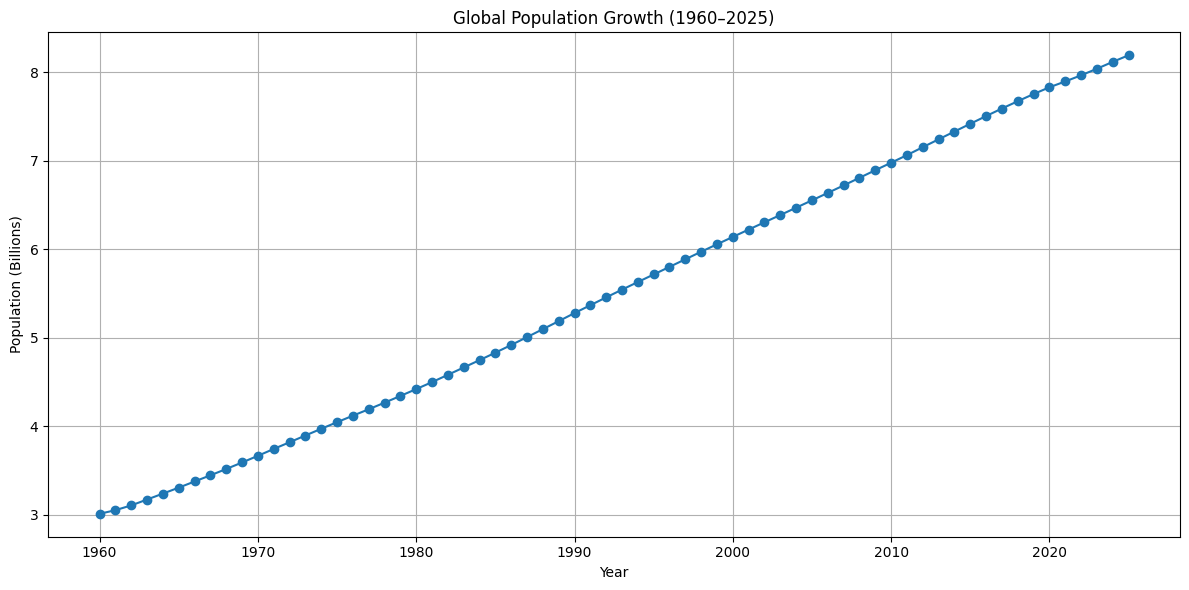

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_population["Year"],
    global_population["Population_Billions"],
    marker="o"
)

plt.title("Global Population Growth (1960–2025)")
plt.xlabel("Year")
plt.ylabel("Population (Billions)")
plt.grid(True)

plt.tight_layout()
plt.show()

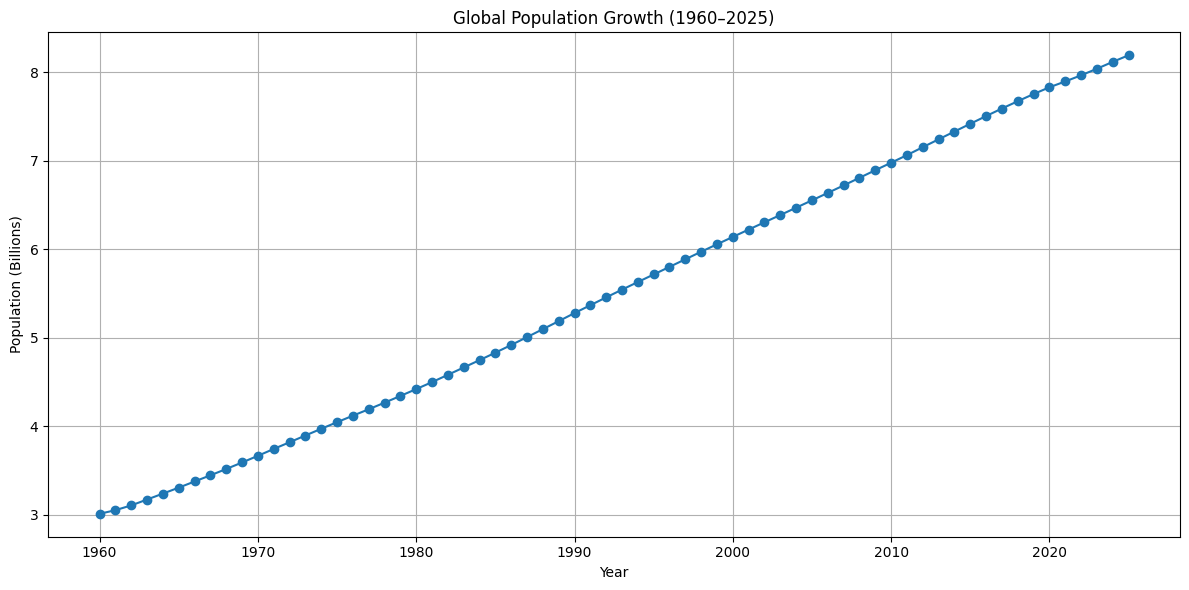

In [12]:
FIGURES_DIR = BASE_DIR / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(12, 6))

plt.plot(
    global_population["Year"],
    global_population["Population_Billions"],
    marker="o"
)

plt.title("Global Population Growth (1960–2025)")
plt.xlabel("Year")
plt.ylabel("Population (Billions)")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "global_population_growth_1960_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

4.2 Top 10 Most Populous Countries — 2025

In [13]:
population_2025 = df[
    df["Year"] == 2025
].copy()

top10_2025 = (
    population_2025
    .sort_values("Population", ascending=False)
    .head(10)
)

display(
    top10_2025[
        ["Country Name", "Country Code", "Population"]
    ]
)

,Country Name,Country Code,Population
5939,India,IND,1.463866e+09
2771,China,CHN,1.406585e+09
13661,United States,USA,3.417849e+08
6005,Indonesia,IDN,2.857212e+08
9899,Pakistan,PAK,2.552196e+08
9569,Nigeria,NGA,2.375278e+08
1781,Brazil,BRA,2.128124e+08
1055,Bangladesh,BGD,1.756869e+08
10691,Russian Federation,RUS,1.435133e+08
4289,Ethiopia,ETH,1.354721e+08


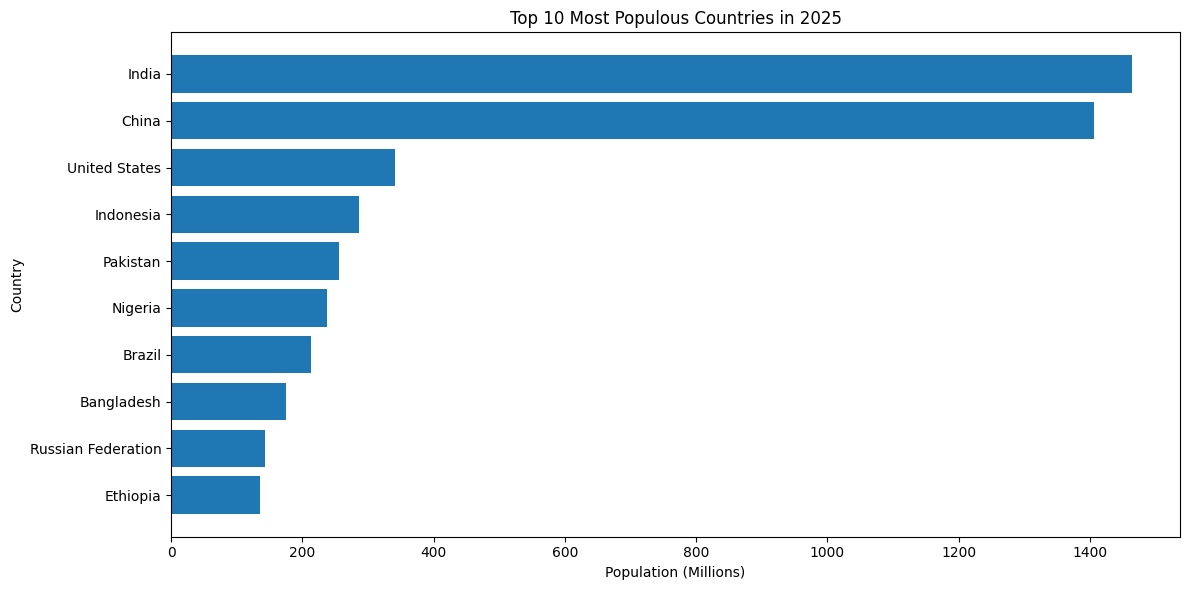

In [14]:
plt.figure(figsize=(12, 6))

plt.barh(
    top10_2025["Country Name"][::-1],
    top10_2025["Population"][::-1] / 1e6
)

plt.title("Top 10 Most Populous Countries in 2025")
plt.xlabel("Population (Millions)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

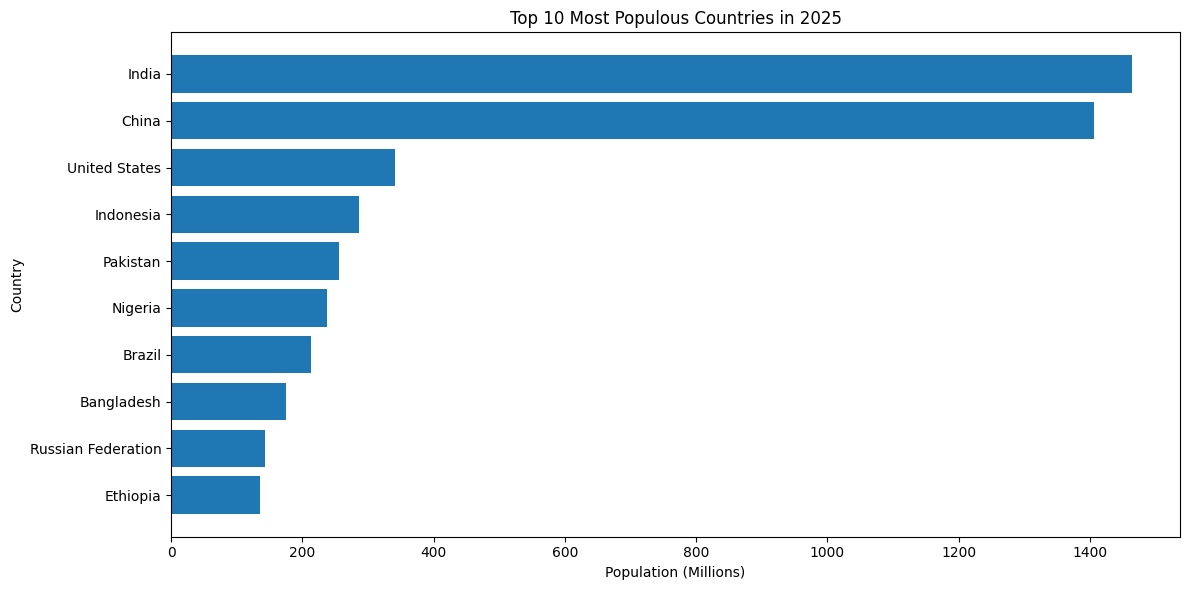

In [15]:
plt.figure(figsize=(12, 6))

plt.barh(
    top10_2025["Country Name"][::-1],
    top10_2025["Population"][::-1] / 1e6
)

plt.title("Top 10 Most Populous Countries in 2025")
plt.xlabel("Population (Millions)")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "top10_population_2025.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

4.3 Population Growth — 1960 to 2025

In [16]:
population_1960 = (
    df[df["Year"] == 1960]
    [["Country Code", "Country Name", "Population"]]
    .rename(columns={"Population": "Population_1960"})
)

population_2025 = (
    df[df["Year"] == 2025]
    [["Country Code", "Population"]]
    .rename(columns={"Population": "Population_2025"})
)

growth = population_1960.merge(
    population_2025,
    on="Country Code"
)

growth["Absolute_Growth"] = (
    growth["Population_2025"]
    - growth["Population_1960"]
)

growth["Growth_Percentage"] = (
    growth["Absolute_Growth"]
    / growth["Population_1960"]
) * 100

growth = growth.sort_values(
    "Growth_Percentage",
    ascending=False
)

display(growth.head(10))

,Country Code,Country Name,Population_1960,Population_2025,Absolute_Growth,Growth_Percentage
204,ARE,United Arab Emirates,131334.0,11513149.0,11381815.0,8666.312608
159,QAT,Qatar,36010.0,2972215.0,2936205.0,8153.860039
172,SXM,Sint Maarten (Dutch part),2715.0,43923.0,41208.0,1517.790055
106,KWT,Kuwait,311060.0,4865298.0,4554238.0,1464.102745
166,SAU,Saudi Arabia,2435403.0,36973555.0,34538152.0,1418.169888
54,DJI,Djibouti,86024.0,1184076.0,1098052.0,1276.448433
99,JOR,Jordan,853471.0,11520684.0,10667213.0,1249.862385
148,OMN,Oman,530485.0,5494691.0,4964206.0,935.786309
14,BHR,Bahrain,165477.0,1600366.0,1434889.0,867.122923
36,CYM,Cayman Islands,8428.0,75844.0,67416.0,799.905078


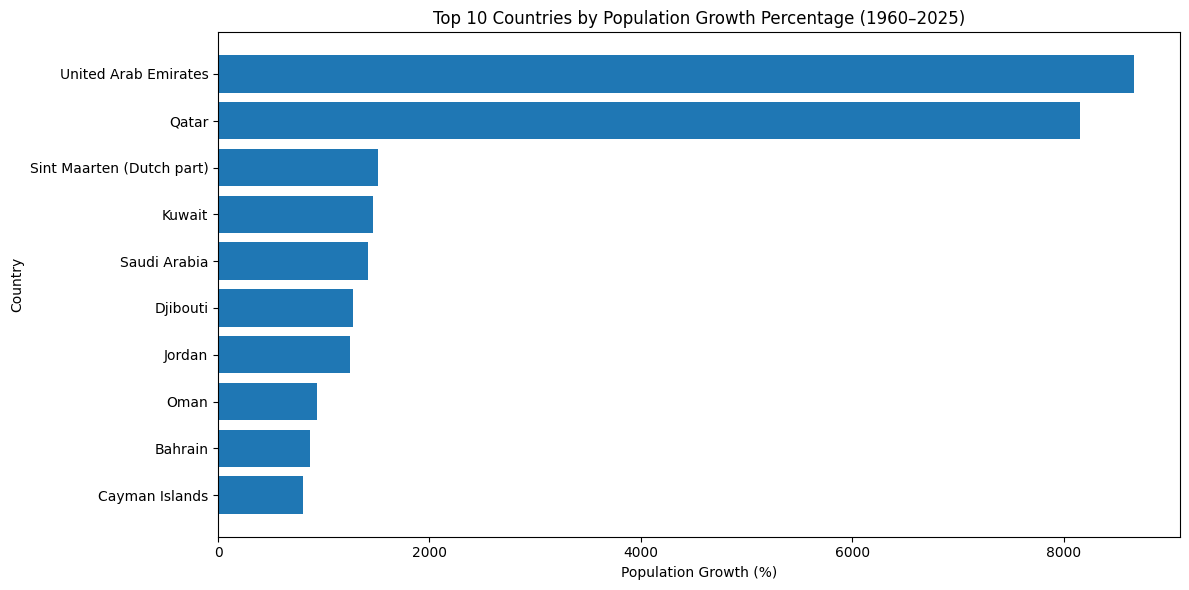

In [17]:
top_growth = growth.head(10)

plt.figure(figsize=(12, 6))

plt.barh(
    top_growth["Country Name"][::-1],
    top_growth["Growth_Percentage"][::-1]
)

plt.title(
    "Top 10 Countries by Population Growth Percentage (1960–2025)"
)

plt.xlabel("Population Growth (%)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

4.4 Sri Lanka Population Trend

In [18]:
sri_lanka = df[
    df["Country Name"] == "Sri Lanka"
].copy()

display(sri_lanka.head())

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Population
11880,Sri Lanka,LKA,"Population, total",SP.POP.TOTL,1960,9661389.0
11881,Sri Lanka,LKA,"Population, total",SP.POP.TOTL,1961,9899372.0
11882,Sri Lanka,LKA,"Population, total",SP.POP.TOTL,1962,10143754.0
11883,Sri Lanka,LKA,"Population, total",SP.POP.TOTL,1963,10395040.0
11884,Sri Lanka,LKA,"Population, total",SP.POP.TOTL,1964,10653397.0


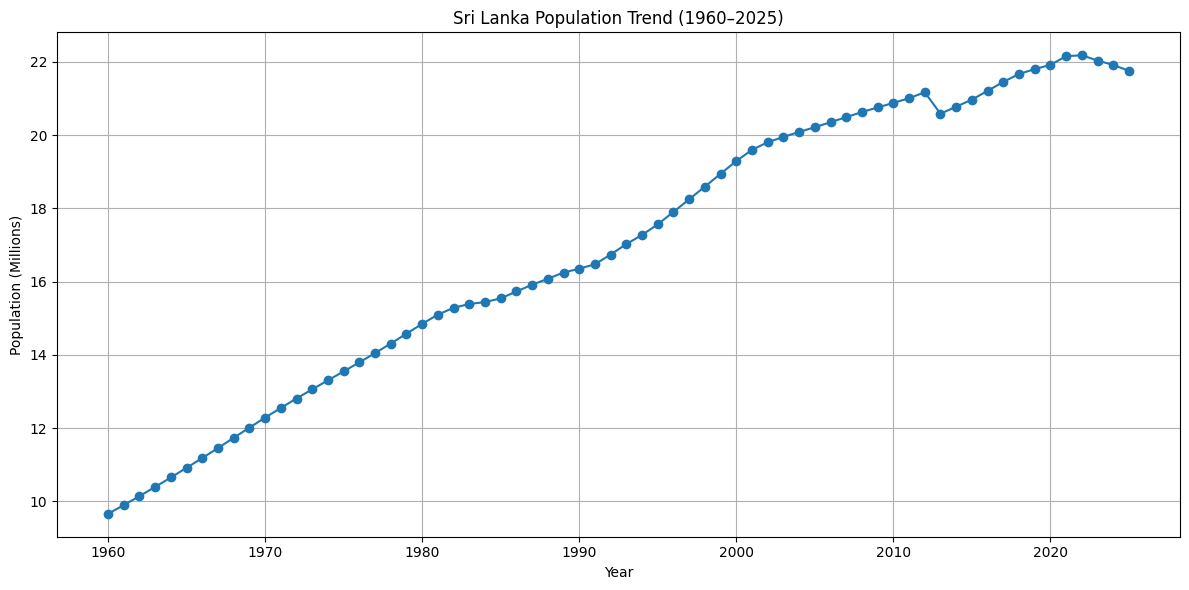

In [19]:
plt.figure(figsize=(12, 6))

plt.plot(
    sri_lanka["Year"],
    sri_lanka["Population"] / 1e6,
    marker="o"
)

plt.title("Sri Lanka Population Trend (1960–2025)")
plt.xlabel("Year")
plt.ylabel("Population (Millions)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
sri_lanka["Annual_Growth_Percentage"] = (
    sri_lanka["Population"]
    .pct_change()
    * 100
)

display(
    sri_lanka[
        ["Year", "Population", "Annual_Growth_Percentage"]
    ].tail(15)
)

,Year,Population,Annual_Growth_Percentage
11931,2011,21009048.0,0.622436
11932,2012,21169458.0,0.763528
11933,2013,20585000.0,-2.760855
11934,2014,20778000.0,0.937576
11935,2015,20970000.0,0.924054
11936,2016,21209000.0,1.139723
11937,2017,21453000.0,1.150455
11938,2018,21670000.0,1.011514
11939,2019,21803000.0,0.613752
11940,2020,21919000.0,0.532037


Population Distribution — 2025

In [23]:
population_2025 = df[df["Year"] == 2025].copy()

print(population_2025.columns.tolist())
print(population_2025.shape)

['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', 'Year', 'Population']
(217, 6)


In [24]:
population_2025 = df[df["Year"] == 2025].copy()

population_2025["Population_Millions"] = (
    population_2025["Population"] / 1_000_000
)

print("Population distribution in 2025:")
print(population_2025["Population_Millions"].describe())

Population distribution in 2025:
count     217.000000
mean       37.751512
std       143.453997
min         0.009492
25%         0.838645
50%         6.549143
75%        27.614411
max      1463.865525
Name: Population_Millions, dtype: float64


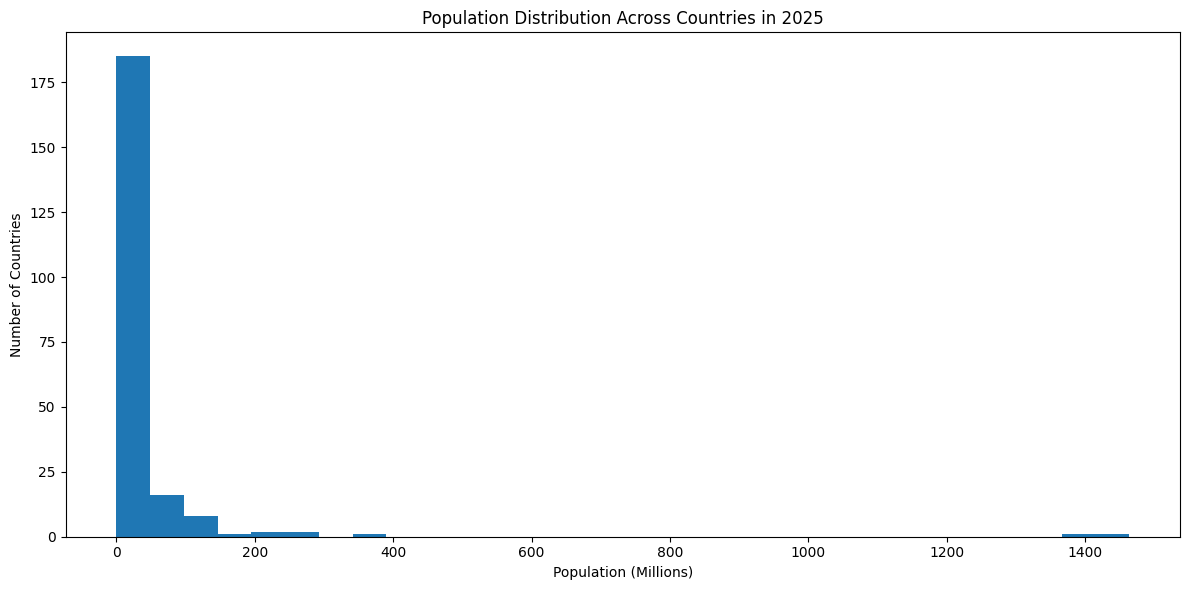

In [25]:
plt.figure(figsize=(12, 6))

plt.hist(
    population_2025["Population_Millions"],
    bins=30
)

plt.title("Population Distribution Across Countries in 2025")
plt.xlabel("Population (Millions)")
plt.ylabel("Number of Countries")

plt.tight_layout()
plt.show()

4.6 COVID-19 Period Analysis

In [26]:
covid_period = global_population[
    global_population["Year"].between(2018, 2022)
].copy()

covid_period["Annual_Growth_Percentage"] = (
    covid_period["Population"]
    .pct_change()
    * 100
)

display(covid_period)

,Year,Population,Population_Billions,Annual_Growth_Percentage
58,2018,7.672585e+09,7.672585,NaN
59,2019,7.753571e+09,7.753571,1.055524
60,2020,7.830279e+09,7.830279,0.989323
61,2021,7.896080e+09,7.896080,0.840343
62,2022,7.965364e+09,7.965364,0.877441


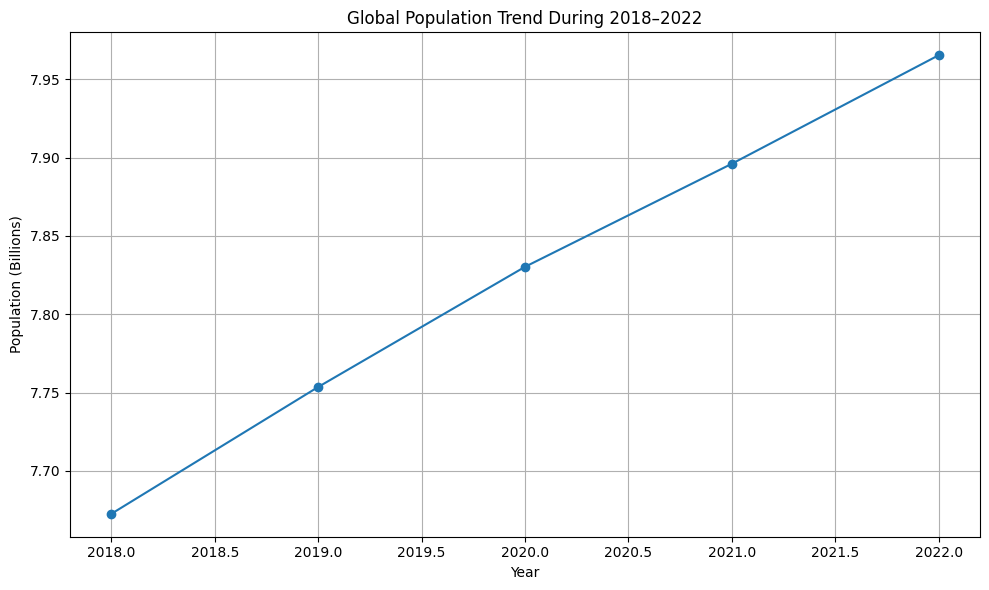

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    covid_period["Year"],
    covid_period["Population_Billions"],
    marker="o"
)

plt.title("Global Population Trend During 2018–2022")
plt.xlabel("Year")
plt.ylabel("Population (Billions)")
plt.grid(True)

plt.tight_layout()
plt.show()

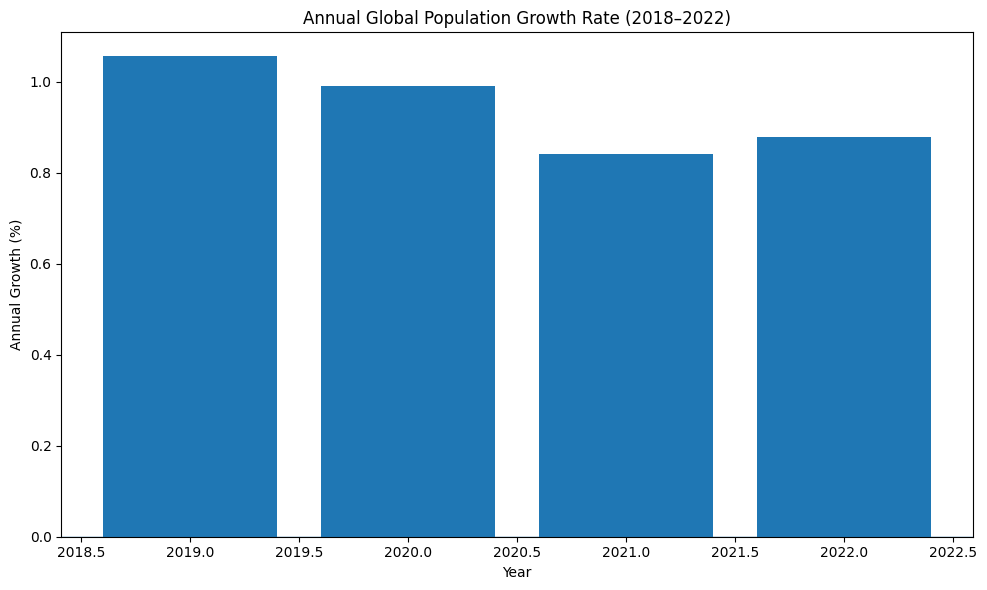

In [28]:
plt.figure(figsize=(10, 6))

plt.bar(
    covid_period["Year"],
    covid_period["Annual_Growth_Percentage"]
)

plt.axhline(
    y=0,
    linewidth=1
)

plt.title("Annual Global Population Growth Rate (2018–2022)")
plt.xlabel("Year")
plt.ylabel("Annual Growth (%)")

plt.tight_layout()
plt.show()

.7 Overall Annual Growth Rate

In [29]:
global_population["Annual_Growth_Percentage"] = (
    global_population["Population"]
    .pct_change()
    * 100
)

display(global_population.tail(10))

,Year,Population,Population_Billions,Annual_Growth_Percentage
56,2016,7.504713e+09,7.504713,1.174096
57,2017,7.590236e+09,7.590236,1.139590
58,2018,7.672585e+09,7.672585,1.084937
59,2019,7.753571e+09,7.753571,1.055524
60,2020,7.830279e+09,7.830279,0.989323
61,2021,7.896080e+09,7.896080,0.840343
62,2022,7.965364e+09,7.965364,0.877441
63,2023,8.039550e+09,8.039550,0.931360
64,2024,8.117485e+09,8.117485,0.969389
65,2025,8.192078e+09,8.192078,0.918924


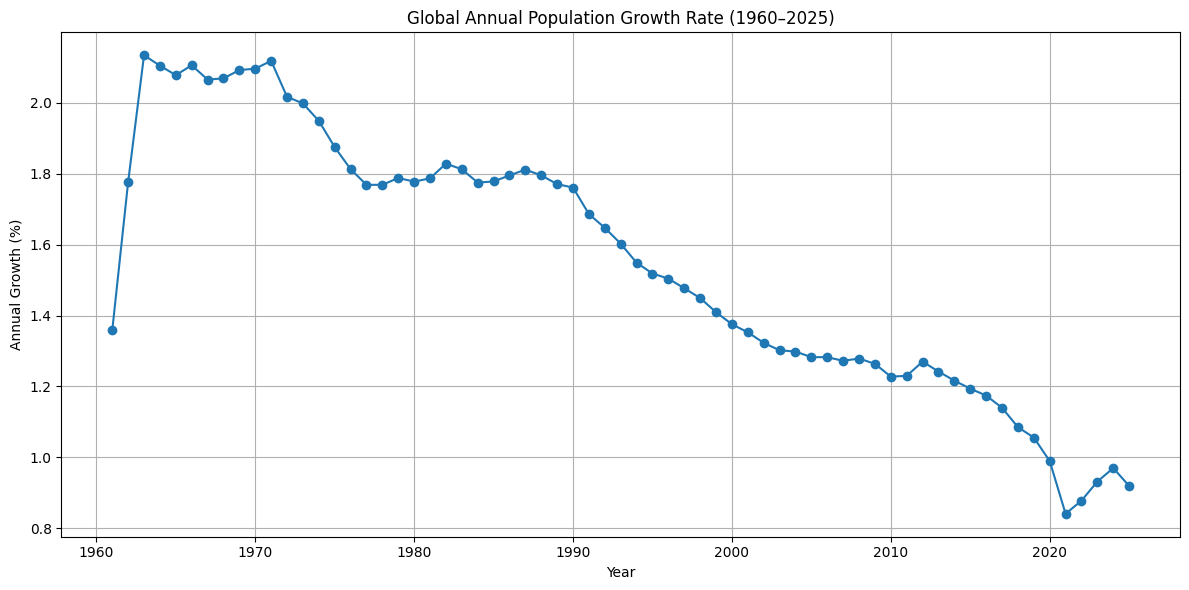

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(
    global_population["Year"],
    global_population["Annual_Growth_Percentage"],
    marker="o"
)

plt.title("Global Annual Population Growth Rate (1960–2025)")
plt.xlabel("Year")
plt.ylabel("Annual Growth (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

4.8 Save EDA Results

In [31]:
TABLES_DIR = BASE_DIR / "outputs" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

global_population.to_csv(
    TABLES_DIR / "global_population_by_year.csv",
    index=False
)

top10_2025.to_csv(
    TABLES_DIR / "top10_population_2025.csv",
    index=False
)

growth.to_csv(
    TABLES_DIR / "population_growth_1960_2025.csv",
    index=False
)

sri_lanka.to_csv(
    TABLES_DIR / "sri_lanka_population_1960_2025.csv",
    index=False
)

covid_period.to_csv(
    TABLES_DIR / "covid_population_analysis_2018_2022.csv",
    index=False
)

print("EDA results saved successfully!")

EDA results saved successfully!


## EDA Findings

The exploratory analysis was conducted using population data for 217 countries covering the period from 1960 to 2025.

### Global Population Trend
The global population showed a long-term increasing trend between 1960 and 2025. However, the annual population growth rate varied over time.

### Population Concentration
The 2025 analysis showed that population is highly concentrated among a relatively small number of countries.

### Country-Level Population Growth
Population growth varied substantially across countries between 1960 and 2025. Some countries experienced much higher percentage growth than others.

### Sri Lanka
Sri Lanka's population increased substantially over the historical period. The annual growth rate varied across different periods.

### Population Distribution
The 2025 population distribution showed a large difference between highly populated countries and countries with smaller populations.

### COVID-19 Period
The 2018–2022 analysis was used to compare global population growth rates before and during the COVID-19 period. This analysis identifies changes in population trends but does not establish a direct causal relationship between COVID-19 and population changes.

### Implications for Machine Learning
The observed long-term trends and country-level differences indicate that historical population patterns can be used as inputs for developing future population prediction models.